## what is machine learning 
machine learning is the process where machine learns pattern to evaluate it code 
**Traditional Programming:**
```
Data + Rules → Output
```

**Machine Learning:**
```
Data + Output → Rules (learned automatically)```

### 3 types of ML
### Supervised learning 
--- you give model a ***labelled data***(input + correct answer)
--it learns to predict the answer for new inputs 

ex. show 1000 mail labelled spam/not spam
-> model learns to detect spam on itd own 

** two subtypes: 
1.regression*** -predicts a  number( house prices)
2. classifications - predicts a category(spam or not ) 


### Unsupervised learning 
you give a model unlabelled data** it wil find a hidden patterns or groups on its own 

example . you gave a 10k buyer list  it will found "budget buyers","premium buyers"

3. Reinforcement learning 
a models learns via trail and error with rewards penalties
used in game robotics, self driving cars

ex. alphago learning chess - gets rewarded  for winning moves 


In [6]:
# step 1 - import the model
from sklearn.linear_model import LinearRegression 

#2- create the model projects 
model = LinearRegression()

#3. train it on data(this is where learning happens)
model.fit(X_train, y_train)

#STEP 4 MAKE predictions
predictions = model.predict(X_test)

#evaluate how good it is 
score = model.score(X_test,Y_test)

""" This `.fit()` → `.predict()` → `.score()` pattern is used for **every single algorithm** in sklearn. Learn it once, use it forever. """

NameError: name 'X_train' is not defined

Why data must be cleaned before ML
Splitting data with train_test_split
Scaling features with StandardScaler
Encoding categories with LabelEncoder

Why data must be cleaned before MLMachine learning models are essentially mathematical functions. They don't have "common sense," so if your data contains errors, the model learns those errors as facts. This is often called GIGO: Garbage In, Garbage Out.Handling Missing Values: Most algorithms crash if they encounter a "Null" or "NaN" value.Removing Outliers: A single data point that is wildly incorrect (like a person's age listed as 250) can skew the entire mathematical average and mislead the model.Consistency: Ensuring "New York," "NY," and "ny" are all treated as the same entity so the model sees the correct patterns.
2. Splitting data with train_test_splitIf you give a student the exact questions and answers to a test before they take it, you haven't measured their intelligence—you’ve measured their memory.The Training Set: Used to "teach" the model.The Test Set: Acts as a final exam with data the model has never seen before.The Goal: We do this to prevent overfitting, where a model becomes a master at "memorizing" the training data but fails miserably when it encounters real-world data it hasn't seen yet.

3. Scaling features with StandardScalerMany ML algorithms calculate the distance between data points to find patterns. If your features have different scales, the model will be biased toward the larger numbers.The Problem: Imagine a dataset with "Age" (0–100) and "Annual Salary" (0–200,000). The model will think Salary is 2,000 times more important than Age just because the numbers are bigger.The Solution: StandardScaler shifts the data so it has a mean of 0 and a standard deviation of 1. It puts everyone on a level playing field without losing the original distribution.

4. Encoding categories with LabelEncoderComputers are great at math, but they don't understand words. They can't calculate the square root of "Apple."The Translation: LabelEncoder converts text labels into numbers. For example:"Red" $\rightarrow$ 0"Green" $\rightarrow$ 1"Blue" $\rightarrow$ 2The Warning: Use this for ordinal data (where order matters, like "Small, Medium, Large"). For nominal data (where there is no order, like "Country"), we usually use "One-Hot Encoding" to prevent the model from thinking that 2 is "better" than 0.

Module 2 — Data Preprocessing
Before feeding data into any ML model, it needs to be cleaned and prepared. This is called preprocessing — and it can make or break your model's performance.

Why Preprocessing Matters
Raw Data → Messy, inconsistent, wrong scale, text values
ML Model → Expects clean numbers, consistent scale, no nulls
Imagine predicting house prices with:

Age column: values like 5, 10, 45 (small numbers)
Price column: values like 500000, 1200000 (huge numbers)

In [2]:
import pandas as pd 
import numpy as np

data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'attendance':    [60, 65, 70, 75, 80, 85, 90, 95, 95, 100],
    'grade':         ['F', 'F', 'D', 'C', 'C', 'B', 'B', 'A', 'A', 'A']
}
df = pd.DataFrame(data)
print(df)

   hours_studied  attendance grade
0              1          60     F
1              2          65     F
2              3          70     D
3              4          75     C
4              5          80     C
5              6          85     B
6              7          90     B
7              8          95     A
8              9          95     A
9             10         100     A


💡 Rule of thumb: X is always a DataFrame (2D), y is always a Series (1D)



In [18]:
# x = inputs (what we use to predict)
X = df[['hours_studied','attendance']]

#y = output (what we want to predicts)
y = df['grade']

print("Features(X)")
print(X)

print("\n Target (y):")
print(y)

Features(X)
   hours_studied  attendance
0              1          60
1              2          65
2              3          70
3              4          75
4              5          80
5              6          85
6              7          90
7              8          95
8              9          95
9             10         100

 Target (y):
0    F
1    F
2    D
3    C
4    C
5    B
6    B
7    A
8    A
9    A
Name: grade, dtype: object


In [4]:
# x = inputs (what we use to predict)
X = df[['hours_studied','attendance']]

#y = output (what we want to predicts)
y = df['grade']

print("Features(X)")
print(X)

print("\n Target (y):")
print(y)

Features(X)
   hours_studied  attendance
0              1          60
1              2          65
2              3          70
3              4          75
4              5          80
5              6          85
6              7          90
7              8          95
8              9          95
9             10         100

 Target (y):
0    F
1    F
2    D
3    C
4    C
5    B
6    B
7    A
8    A
9    A
Name: grade, dtype: object


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test =train_test_split(
    X,     # features
    y,     #target
    test_size = 0.2,    # 20% goes to test
    random_state = 42 # ensures same split every run )
)

print("Training  size ", len(X_train))
print("Testing size:", len(X_test))



Training  size  8
Testing size: 2


## why random_state = 42 ??

#### without it the split is random every run - your results would change every time  

In [16]:
print("X_train : \n", X_train)
print("\nX_test: \n", X_test)

X_train : 
    hours_studied  attendance
5              6          85
0              1          60
7              8          95
2              3          70
9             10         100
4              5          80
3              4          75
6              7          90

X_test: 
    hours_studied  attendance
8              9          95
1              2          65


## step 3

### statndardScalling Featurescaling

Different columns have different ranges. Scaling brings them to the **same scale**.
hours_studied: 1–10     (small range)
attendance:   60–100    (larger range)

## Without scaling, the model gives more importance to attendance just because the numbers are bigger — even if hours_studied matters more!




In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling (X_train):")
print(X_train.values)

print("\nAfter Scaling:")
print(X_train_scaled)


Before scaling (X_train):
[[  6  85]
 [  1  60]
 [  8  95]
 [  3  70]
 [ 10 100]
 [  5  80]
 [  4  75]
 [  7  90]]

After Scaling:
[[ 0.18569534  0.25031309]
 [-1.67125804 -1.75219161]
 [ 0.92847669  1.05131497]
 [-0.92847669 -0.95118973]
 [ 1.67125804  1.45181591]
 [-0.18569534 -0.15018785]
 [-0.55708601 -0.55068879]
 [ 0.55708601  0.65081403]]


# critical rules 
# ✅ CORRECT
scaler.fit_transform(X_train)   # learn scale FROM training data
scaler.transform(X_test)        # apply SAME scale to test data

# ❌ WRONG
scaler.fit_transform(X_test)    # never fit on test data!

# step 4
label encoderc

ML models only understand numbers, not text. We must convert 'A', 'B', 'C', 'D', 'F' into numbers.


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

Y_train_encoded =le.fit_transform(Y_train)
Y_test_encoded = le.transform(Y_test)

print("Original grades:", list(Y_train))
print("Encoded grades:", Y_train_encoded)


Original grades: ['B', 'F', 'A', 'D', 'A', 'C', 'C', 'B']
Encoded grades: [1 4 0 3 0 2 2 1]


## ✅ Module 2 Summary
 ### StepToolPurposeSeparate X & y Pandas  Split features from target 
 Split data train_test_split      80% train, 20% testScale 
 
 numbersStandardScalerEqual importance to all featuresEncode 
 
 textLabelEncoderConvert categories to numbers

Module 3 — Linear Regression
Our first ML model! This is the foundation of all machine learning. Master this and everything else becomes easier 

### create a model and train it 

In [12]:
# create the model 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
# train it 
model.fit(X_train_scaled, Y_train_encoded)

print("model trained")

# see what model learned 
print(f"\nslope (coefficients): {model.coef_}")
print(f" Intercept:  {model.intercept_:.2f}")

model trained

slope (coefficients): [ 1.12558773 -2.41500835]
 Intercept:  1.62


### exam_score = (17.23 × hours_studied) + (5.84 × attendance) + 72.50

## make predictions 

In [22]:
# predict on the test data 
y_pred = model.predict(X_test_scaled)


#compare predictions vs actual

results = pd.DataFrame({
    'Actual Score': Y_test.values,
    'Predicted Score': y_pred.round(1)
})
print(results)

  Actual Score  Predicted Score
0            A              0.5
1            F              3.4


In [23]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test_encoded, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MSE: 0.32
RMSE: 0.56


### quared
Measures how well the model explains the variation in data

Output:
```
R² Score: 0.97
```
```
R² = 1.0  → Perfect model (rare!)
R² = 0.97 → Explains 97% of variation ✅ Excellent
R² = 0.60 → Explains 60% — OK but improvable
R² = 0.0  → Model learned nothing
R² < 0    → Worse than a random guess ❌

In [24]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test_encoded, y_pred)
print(f"R² Score: {r2:.2f}")

R² Score: 0.92


### Step 5 — Visualize the Results

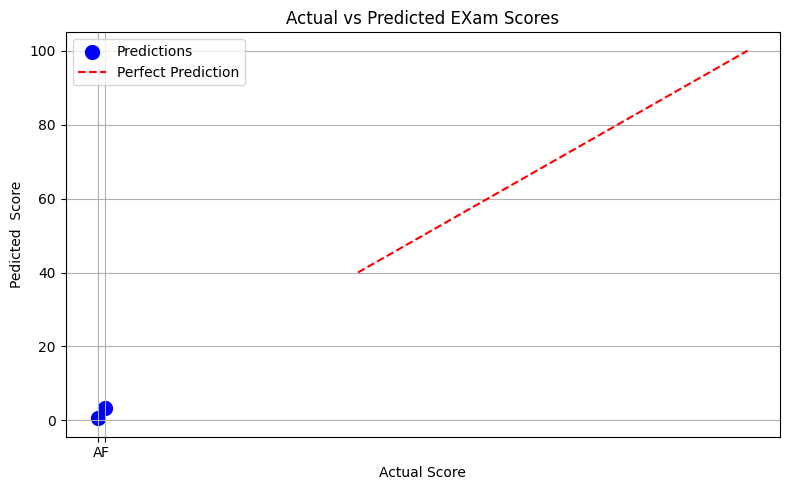

In [28]:
import matplotlib.pyplot as plt 
plt.figure(figsize = (8,5))

#Plot actual vs predicted 
plt.scatter(Y_test, y_pred, color = 'blue', s = 100, label = 'Predictions')

#Perfect prediction line 
plt.plot([40,100], [40,100], color ='red',
         linestyle = '--',label = 'Perfect Prediction')

plt.xlabel('Actual Score')
plt.ylabel('Pedicted  Score')
plt.title('Actual vs Predicted EXam Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1/(1 + np.exp(-z))

z = np.linespace(-10, 10, 100)
plt.plot(z, sigmoid(z), color ='blue', linewidth = 2)
